
#Domain-Specific vs General-Purpose LLMs for XAI
## Heart Disease Prediction - Framingham Heart Study
**MSc Artificial Intelligence** - 2026

# Data Loading and Exploratory Data Analysis

This notebook performs the initial exploration of the Framingham Heart Study dataset.

The objectives are to:

- Load the dataset
- Inspect the dataset structure
- Explore feature types
- Identify missing values
- Examine the target variable
- Generate descriptive statistics

This notebook forms the foundation for the preprocessing and modelling stages developed later in the project.

## 1. Loading the Framingham HEART Study Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Project Configuration
from pathlib import Path
RANDOM_STATE = 42
DATA_PATH = Path("data/framingham.csv")
print("Dataset loaded")

Dataset loaded


In [3]:
!pip install -q optuna  # Hypermeter optimisation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 5.4 MB/s eta 0:00:00


In [23]:
# Importing the Libraries necessary
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import shap
warnings.filterwarnings("ignore")

np.random.seed(RANDOM_STATE)

print("Libraries imported ")

Libraries imported 


## 2. Exploratory Data Analysis (EDA)

In [5]:
# Load Framingham Heart Study dataset
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/framingham.csv")
df.info()
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.describe().round(2)
print(f"Dataset loaded successfully.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB
Rows: 4240
Co

,Missing Count,Missing Percentage
glucose,388,9.15
education,105,2.48
BPMeds,53,1.25
totChol,50,1.18
cigsPerDay,29,0.68
BMI,19,0.45
heartRate,1,0.02


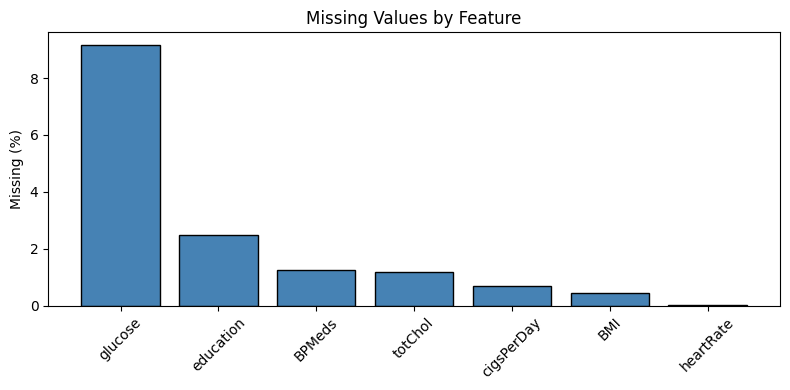

In [6]:
# Missing Value Analysis
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing,"Missing Percentage": missing_pct})
missing_df = (missing_df[missing_df["Missing Count"] > 0].sort_values("Missing Percentage", ascending=False))
display(missing_df)

plt.figure(figsize=(8,4))

plt.bar(missing_df.index,missing_df["Missing Percentage"],color="steelblue",edgecolor="black")

plt.title("Missing Values by Feature")
plt.ylabel("Missing (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

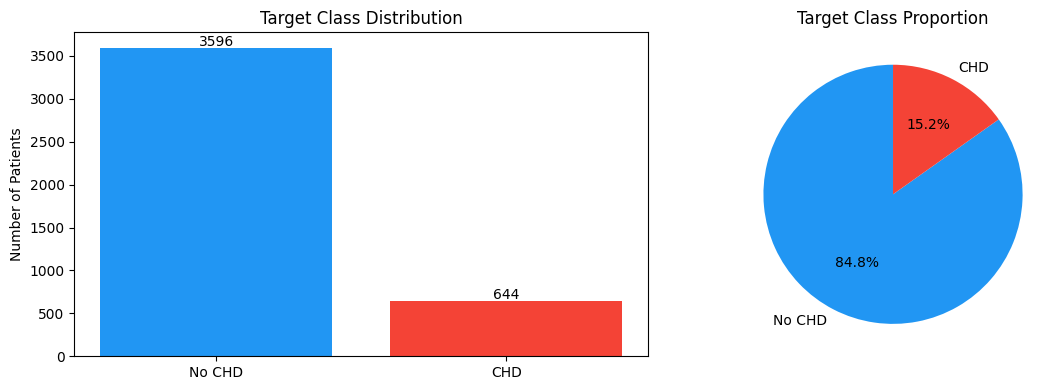

In [7]:
# Target Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
counts = df["TenYearCHD"].value_counts()

ax[0].bar(["No CHD","CHD"],counts.values,color=['#2196F3', '#F44336'])
ax[0].set_title("Target Class Distribution")
ax[0].set_ylabel("Number of Patients")

for i, value in enumerate(counts.values):
  ax[0].text(i, value + 20, str(value), ha="center")

ax[1].pie(counts.values,labels=["No CHD","CHD"],autopct="%.1f%%",colors=['#2196F3', '#F44336'],startangle=90)
ax[1].set_title("Target Class Proportion")
plt.tight_layout()
plt.show()

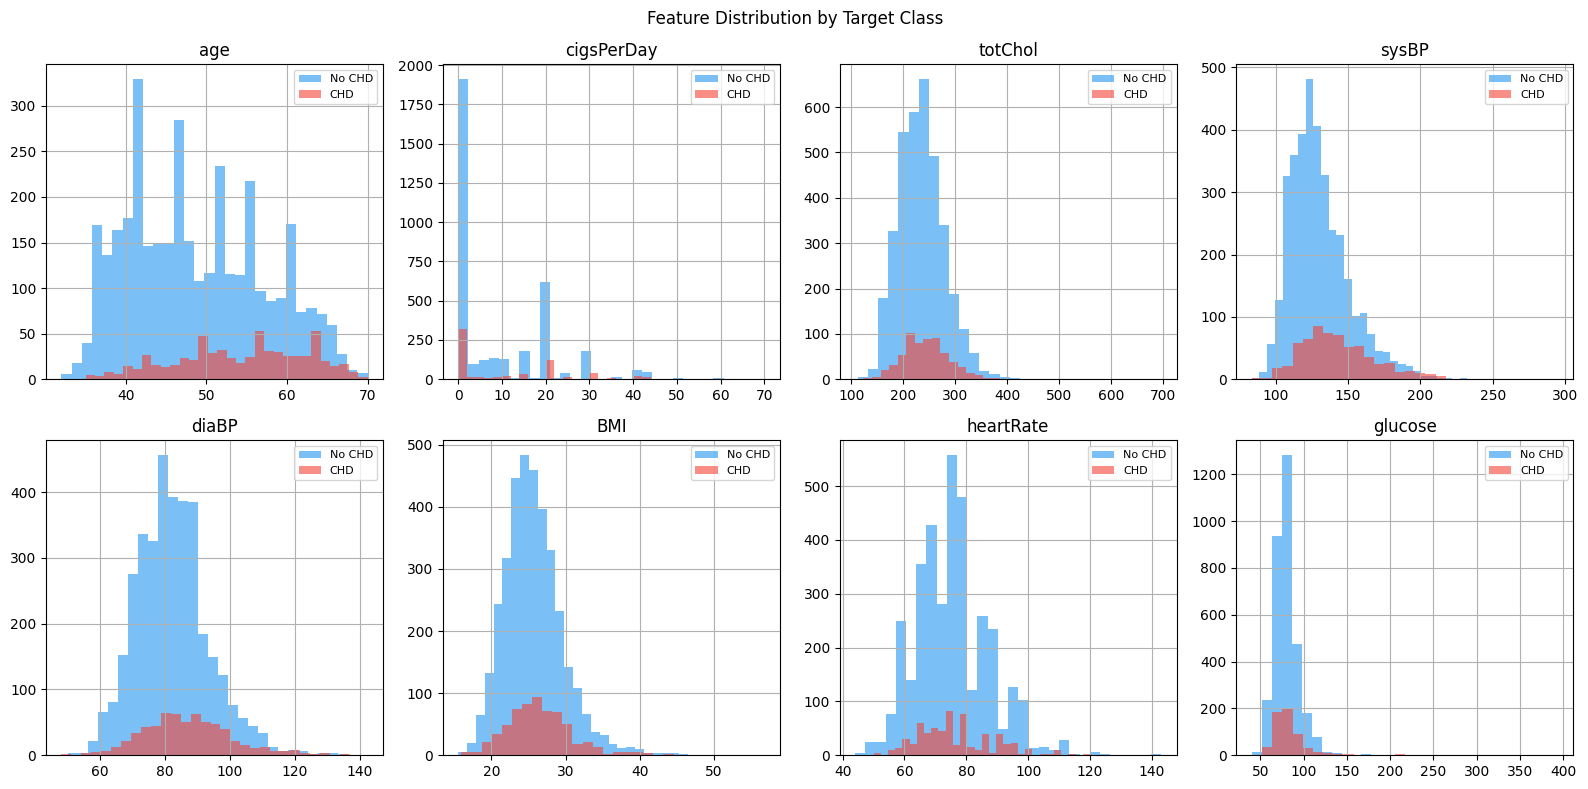

In [8]:
# Feature Distributions by CHD status
continuous_features = ["age","cigsPerDay","totChol","sysBP","diaBP","BMI","heartRate","glucose"]

fig, ax = plt.subplots(2,4,figsize=(16,8))
ax = ax.flatten()
for i, feature in enumerate(continuous_features):
    df[df['TenYearCHD'] == 0][feature].dropna().hist(
        ax=ax[i], bins=30, alpha=0.6, color='#2196F3', label='No CHD')
    df[df['TenYearCHD'] == 1][feature].dropna().hist(
        ax=ax[i], bins=30, alpha=0.6, color='#F44336', label='CHD')
    ax[i].set_title(feature)
    ax[i].legend(fontsize=8)
plt.suptitle("Feature Distribution by Target Class")
plt.tight_layout()
plt.show()


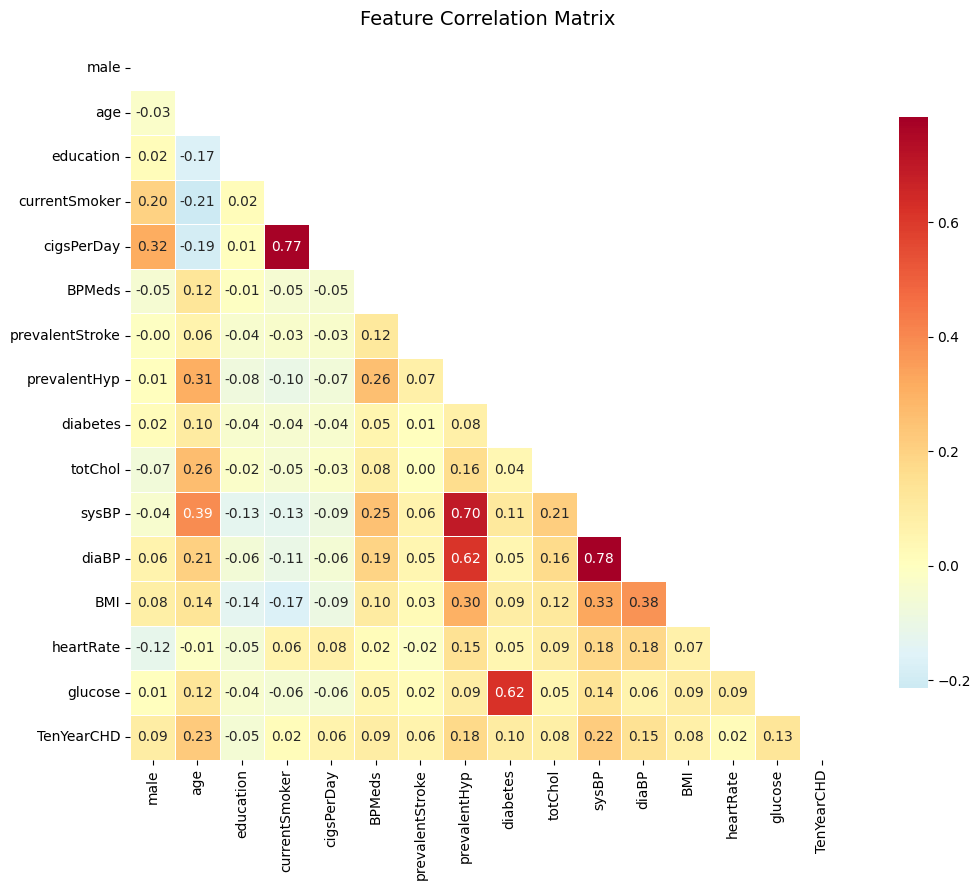

In [9]:
# Correlation Heatmap
plt.figure(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix , dtype=bool))
sns.heatmap(corr_matrix,mask=mask , annot=True , fmt='.2f',cmap='RdYlBu_r', center=0,square=True,linewidth=0.5,cbar_kws={'shrink':0.8})
plt.title("Feature Correlation Matrix",fontsize=14,pad=15)
plt.tight_layout()
plt.show()


## 3. Data Preprocessing

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

TARGET = "TenYearCHD"
FEATURES = [col for col in df.columns if col !=TARGET]

X = df[FEATURES].copy()
y = df[TARGET].copy()

TEST_SIZE = 0.2 # Defining TEST_SIZE

print(f'Features ({len(FEATURES)}): {FEATURES}')
# Stratified split FIRST , then fit imputer on train only
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
imputer = SimpleImputer(strategy = 'median')
X_train = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=FEATURES)
X_test = pd.DataFrame(imputer.transform(X_test_raw) , columns = FEATURES)
print(f'Missing after imputation - Train: {X_train.isnull().sum().sum()}, Test : {X_test.isnull().sum().sum()}')

print(f'\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train CHD prevalence: {y_train.mean()*100:.1f}%')
print(f'Test CHD prevalence: {y_test.mean()*100:.1f}%')

Features (15): ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
Missing after imputation - Train: 0, Test : 0

Train: 3392 | Test: 848
Train CHD prevalence: 15.2%
Test CHD prevalence: 15.2%


Logistic Regression   ROC-AUC=0.7287 | PR-AUC=0.3480 |Balanced Acc=0.6781
Random Forest         ROC-AUC=0.7036 | PR-AUC=0.3309 |Balanced Acc=0.5725
XGBoost               ROC-AUC=0.6948 | PR-AUC=0.3350 |Balanced Acc=0.5697

Baseline Comparison
                     ROC-AUC  ROC-AUC Std  PR-AUC  PR-AUC Std  \
Logistic Regression   0.7287       0.0283  0.3480      0.0458   
Random Forest         0.7036       0.0271  0.3309      0.0359   
XGBoost               0.6948       0.0305  0.3350      0.0472   

                     Balanced Accuracy  
Logistic Regression             0.6781  
Random Forest                   0.5725  
XGBoost                         0.5697  


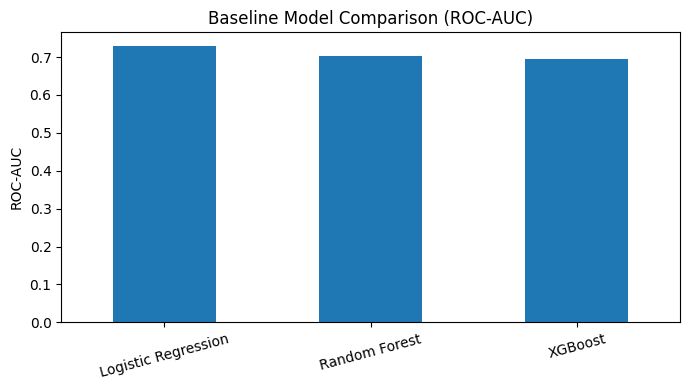

In [11]:
# SMOTE inside CV folds using imblearn Pipeline
# SMOTE is applied  only to the training folds

from sklearn.model_selection import StratifiedKFold, cross_validate # Changed cross_val_score to cross_validate
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler # Added import for StandardScaler
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt # Added import for plt
from pathlib import Path # Added import for Path

# Define CV_FOLDS and OUTPUT_DIR
CV_FOLDS = 5 # Defined CV_FOLDS
OUTPUT_DIR = Path("output") # Defined OUTPUT_DIR
OUTPUT_DIR.mkdir(exist_ok=True) # Create the output directory if it doesn't exist

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE) # Removed trailing comma

models = {
    "Logistic Regression": ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scalar" , StandardScaler()),
        ("smote", SMOTE(random_state = RANDOM_STATE)),
        ("clf", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE
        ))
    ]),

    "XGBoost": ImbPipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            verbosity=0
        ))
    ]),
}

scoring = {
    "ROC-AUC": "roc_auc",
    "PR-AUC": "average_precision",
    "Balanced Accuracy": "balanced_accuracy"
}

results = {}

for name,model in models.items():
    scores = cross_validate(
        model,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)

    results[name] = {
        "ROC-AUC": scores["test_ROC-AUC"].mean(),
        "ROC-AUC Std": scores["test_ROC-AUC"].std(),
        "PR-AUC": scores["test_PR-AUC"].mean(),
        "PR-AUC Std": scores["test_PR-AUC"].std(),
        "Balanced Accuracy": scores["test_Balanced Accuracy"].mean()}

    print(f"{name:22}"
    f"ROC-AUC={scores['test_ROC-AUC'].mean():.4f} | "
    f"PR-AUC={scores['test_PR-AUC'].mean():.4f} |" # Corrected f-string syntax
    f"Balanced Acc={scores['test_Balanced Accuracy'].mean():.4f}")

baseline_df = pd.DataFrame(results).T.round(4)

print("\nBaseline Comparison")
print(baseline_df)

baseline_df.to_csv(
    f"{OUTPUT_DIR}/baseline_comparison.csv"
)
baseline_df["ROC-AUC"].plot(kind ="bar",figsize=(7,4),title="Baseline Model Comparison (ROC-AUC)"
) # Removed extraneous parenthesis

plt.ylabel("ROC-AUC")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
# Removed redundant print statement and extraneous parenthesis at the very end


##4. XGBoost Hyperparameter Optmisation - Optuna

In [12]:
# Optuna runs 50 trail of Bayesian optimisation , maximising CV ROC-AUC.
# SMOTE is correctly applied inside each fold .
OPTUNA_TRAILS = 50 # Bayesian HPO trails for XGBOOST
import optuna
def xgb_objective(trail):
  """Optuna objective : 5-fold CV ROC-AUC with SMOTE inside each fold."""
  params = {
      "n_estimators": trail.suggest_int("n_estimators",100,600),
      "max_depth": trail.suggest_int("max_depth",3,8),
      "learning_rate": trail.suggest_float("learning_rate" , 0.01,0.3,log=True),
      "subsample": trail.suggest_float("subsample",0.5,1.0),
      "colsample_bytree": trail.suggest_float("colsample_bytree",0.5,1.0),
      "min_child_weight": trail.suggest_int("min_child_weight",1,10),
      "gamma": trail.suggest_float("gamma",0.0,1.0),
      "reg_alpha": trail.suggest_float("reg_alpha",1e-8,10.0,log=True),
      "reg_lambda": trail.suggest_float("reg_lambda",1e-8,10.0,log=True),
      "use_label_encoder": False,
      "eval_metric":"logloss",
      "random_state": RANDOM_STATE,
      "verbosity": 0,
  }
  clf = xgb.XGBClassifier(**params)
  pipe = ImbPipeline([('smote',SMOTE(random_state=RANDOM_STATE)),("clf",clf)])
  scores = cross_validate(pipe , X_train, y_train , cv=cv , scoring =scoring,n_jobs=-1)
  return scores['test_ROC-AUC'].mean()

print(f"Running Optuna HPO - {OPTUNA_TRAILS} trails...")
study = optuna.create_study(direction= "maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(xgb_objective , n_trials=OPTUNA_TRAILS , show_progress_bar=True)

best_params = study.best_params
best_params.update({"use_labels_encoder": False,"eval_metric": "logloss",
                    "random_state":RANDOM_STATE , "verbosity":0})

print(f'\nBest CV ROC-AUC: {study.best_value:.4f}')
print(f'BEST Hyperparameters:')
for k , v in study.best_params.items():
    print(f' {k}:{v}')

[I 2026-07-20 20:00:44,147] A new study created in memory with name: no-name-ee3e08f1-3435-425b-b02f-eca91e013a6a


Running Optuna HPO - 50 trails...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-20 20:00:47,474] Trial 0 finished with value: 0.666380639979363 and parameters: {'n_estimators': 287, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 2, 'gamma': 0.05808361216819946, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 0.666380639979363.
[I 2026-07-20 20:00:49,353] Trial 1 finished with value: 0.6352512722198771 and parameters: {'n_estimators': 454, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'min_child_weight': 2, 'gamma': 0.18340450985343382, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 0 with value: 0.666380639979363.
[I 2026-07-20 20:00:52,384] Trial 2 finished with value: 0.6858871886872098 and parameters: {'n_estimators': 316, 'max_depth': 4, 'learning_rate': 0.08012737503998542, 'subsample'

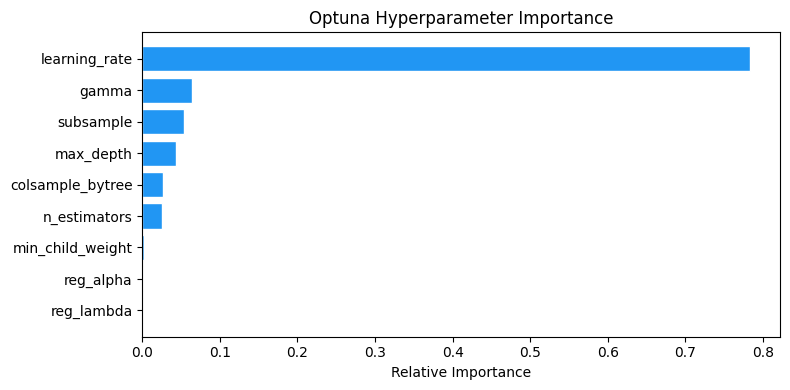

In [13]:
# --- Optuna importance plot ---
try:
    importances = optuna.importance.get_param_importances(study)
    fig, ax = plt.subplots(figsize=(8, 4))
    params_sorted = sorted(importances.items(), key=lambda x: x[1])
    names, vals = zip(*params_sorted)
    ax.barh(names, vals, color='#2196F3', edgecolor='white')
    ax.set_title('Optuna Hyperparameter Importance')
    ax.set_xlabel('Relative Importance')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/optuna_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'Importance plot skipped: {e}')

### 5.Train Final XGBoost with Optimised Hyperparameters

In [14]:
# Apply SMOTE to the training set for the final model
smote_final = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote_final.fit_resample(X_train, y_train)
print(f'After SMOTE - Train size: {X_train_res.shape[0]}')
print(f'Class distribution: {pd.Series(y_train_res).value_counts().to_dict()}')

# Train with best hyperparameters
xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(X_train_res, y_train_res)
print('\nFinal XGBoost trained')

After SMOTE - Train size: 5754
Class distribution: {0: 2877, 1: 2877}

Final XGBoost trained


In [15]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score # Import necessary metrics
from sklearn.model_selection import cross_val_score # Added import for cross_val_score

# Evaluate on test set
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]
print(' The Classification Report')
print(classification_report(y_test,y_pred,target_names=['No CHD','CHD']))
print(f'ROC-AUC Score: {roc_auc_score(y_test,y_prob):.4f}')
print(f'PR-AUC Score: {average_precision_score(y_test,y_prob):.4f}')

# Cross validation on the full dataset using imblearn pipeline
# X_raw still contains the NANs thus the pipeline handles the imputation internally
X_raw = df[[col for col in df.columns if col != 'TenYearCHD']].copy()
y_raw = df['TenYearCHD'].copy()

final_pipe = ImbPipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=RANDOM_STATE)),
    ('clf',xgb.XGBRFClassifier(**best_params))  ])

cv_auc_final = cross_val_score(
    final_pipe,X_raw, y_raw,cv=cv,scoring='roc_auc') # Changed 'roc-auc' to 'roc_auc'
print(f'\n{CV_FOLDS}-Fold CV ROC-AUC (SMOTE inside folds): {cv_auc_final.mean():.4f} \u00b1 {cv_auc_final.std():.4f}')

 The Classification Report
              precision    recall  f1-score   support

      No CHD       0.86      0.94      0.90       719
         CHD       0.33      0.16      0.22       129

    accuracy                           0.82       848
   macro avg       0.60      0.55      0.56       848
weighted avg       0.78      0.82      0.80       848

ROC-AUC Score: 0.6863
PR-AUC Score: 0.2696

5-Fold CV ROC-AUC (SMOTE inside folds): 0.7089 ± 0.0253


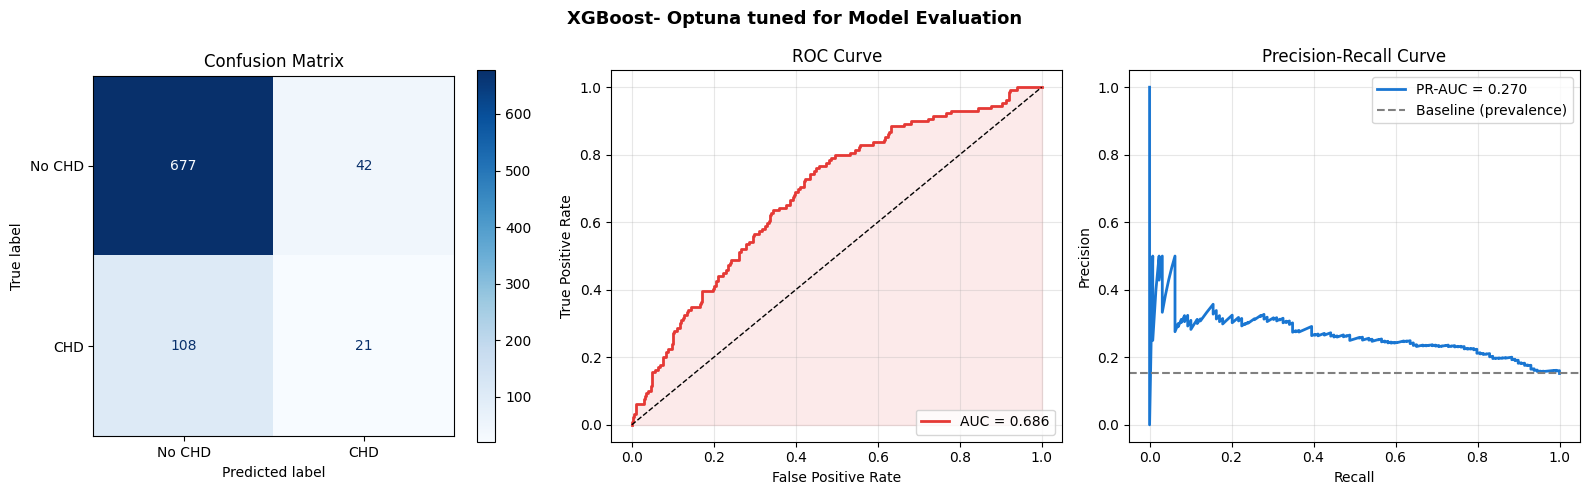

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score # Added roc_curve and roc_auc_score to imports

# Confusion Matrix
fig , axes = plt.subplots(1,3,figsize=(16,5))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,display_labels=['No CHD','CHD'],cmap='Blues',ax=axes[0])
axes[0].set_title('Confusion Matrix')

# ROC curve
fpr,tpr,_ =roc_curve(y_test , y_prob)
auc_score   = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#E53935', lw=2, label=f'AUC = {auc_score:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#E53935')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

# Precision - Recall Curve
from sklearn.metrics import precision_recall_curve
precision_vals,recall_vals,_ = precision_recall_curve(y_test,y_prob)
pr_auc = average_precision_score(y_test,y_prob)
axes[2].plot(recall_vals,precision_vals,color='#1976D2',lw=2,label=f'PR-AUC = {pr_auc:.3f}')
axes[2].axhline(y=y_test.mean(), color='grey', linestyle='--', label='Baseline (prevalence)')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('XGBoost- Optuna tuned for Model Evaluation',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.show()

## 6.SHAP Explainability

In [17]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values shape: {shap_values.shape}')
print(f'TEST set shape: {X_test.shape}')
print(f'Expected value (base rate): {explainer.expected_value:.4f}')

SHAP values shape: (848, 15)
TEST set shape: (848, 15)
Expected value (base rate): 0.0012


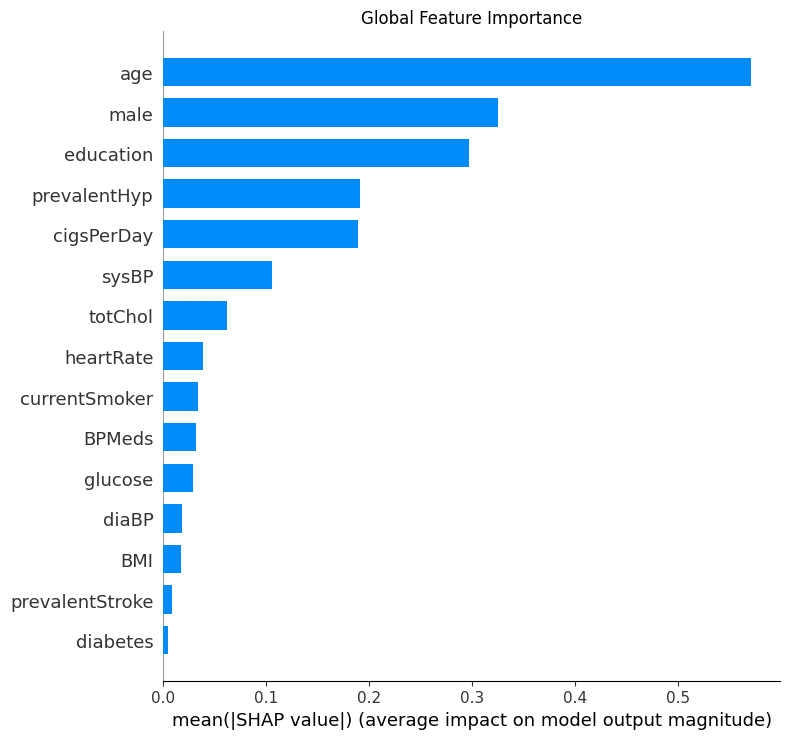

In [18]:
# Global SHAP summary
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values,X_test,plot_type='bar',feature_names=FEATURES , show=False)
plt.title('Global Feature Importance')
plt.tight_layout()
plt.show()

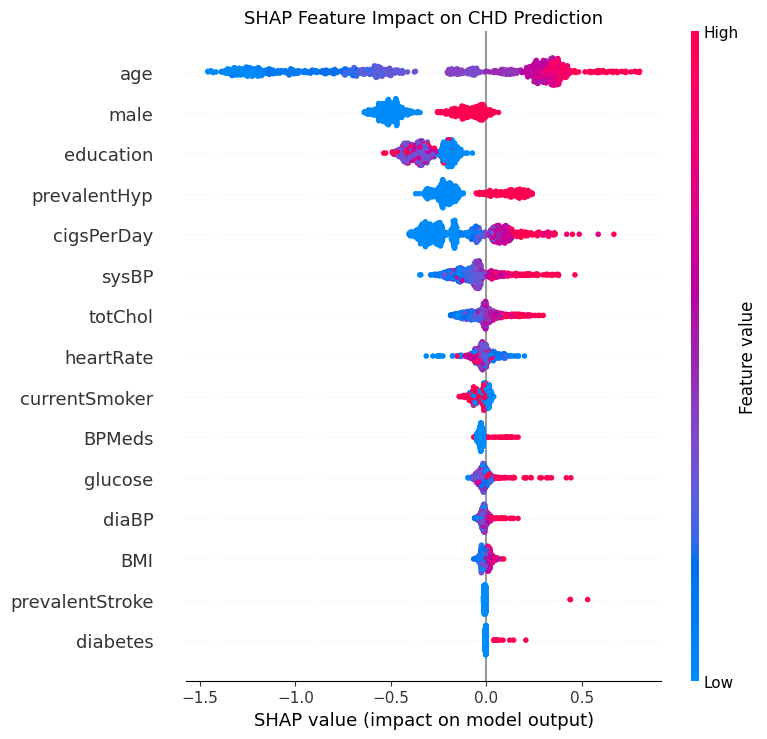

In [19]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Feature Impact on CHD Prediction', fontsize=13)
plt.tight_layout()
plt.show()

Instance #5
 True label: No CHD
  Predicted:   No CHD (prob=0.140)


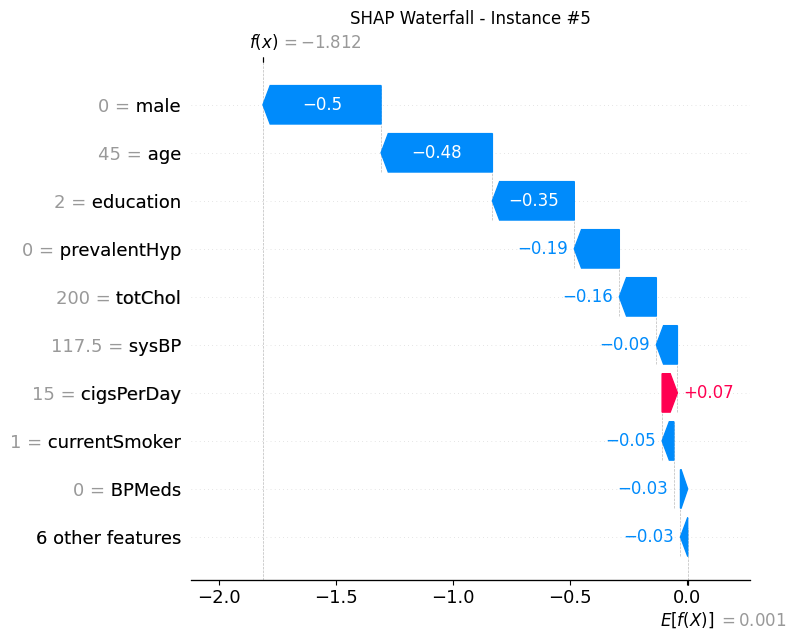

In [24]:
DEMO_INSTANCE_IDX = 5 # Define the instance index
# Individual waterfall for an Instance
instance = X_test.iloc[DEMO_INSTANCE_IDX]
true_label = y_test.iloc[DEMO_INSTANCE_IDX]
pred_prob = xgb_model.predict_proba(instance.values.reshape(1,-1))[0,1]
pred_label = int(pred_prob >= 0.5)

print(f'Instance #{DEMO_INSTANCE_IDX}')
print(f' True label: {"CHD" if true_label == 1 else "No CHD"}')
print(f'  Predicted:   {"CHD" if pred_label == 1 else "No CHD"} (prob={pred_prob:.3f})')

shap_exp = shap.Explanation(values=shap_values[DEMO_INSTANCE_IDX],base_values=explainer.expected_value,data=instance.values,feature_names=FEATURES)
shap.plots.waterfall(shap_exp,show = False)
plt.title(f'SHAP Waterfall - Instance #{DEMO_INSTANCE_IDX}')
plt.tight_layout()
plt.show()

## 7. Structured SHAP for LLM Prompt Builder

In [ ]:
# Human - readable features descriptions for LLM prompts
